In [1]:
import torch
import shutil
import os
import imageio.v2 as imageio
import numpy as np


from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter13_14 import muscl_reconstruction, transmissive_bc
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter16 import strang_update
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter10 import HLLC_Riemann_Solver
from CFD import Simulator
from CFD import create_explosion_initial_condition

from JupyterVisualizer import visualize_voxel, ImageVisualizer

from util import create_boundary_band_solid_mask, create_sphere_solid_mask

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

folder = "/TMP_MOUNT/cells"
folder_full = "/TMP_MOUNT/cells_full"

shutil.rmtree(folder, ignore_errors=True)
os.makedirs(folder, exist_ok=True)


Using device: cuda
CUDA device: NVIDIA GeForce RTX 5080


In [ ]:
#physical quantities--------------------------------------------

X_DOMAIN = [0, 1] # 1 m
Y_DOMAIN = [0, 2] # 1 m
Z_DOMAIN = [0, 1] # 1 m
T_DOMAIN = [0, 1.3]

GAMMA = 1.4

#simulation parameters--------------------------------------------
#z, y, x
#for 2dim simulateion set z_domain to 1
DIMENSION = 2
tmp = 100

if(DIMENSION == 3):
    RESOLUTION = tmp, tmp, tmp
else:
    RESOLUTION = 1, 2000, 1000


DX = (X_DOMAIN[1] - X_DOMAIN[0]) / RESOLUTION[2]
DY = (Y_DOMAIN[1] - Y_DOMAIN[0]) / RESOLUTION[1]
DZ = (Z_DOMAIN[1] - Z_DOMAIN[0]) / RESOLUTION[0]

CFL_COEFFICIENT = 0.6
TOL = 1e-6

#explosion parameters--------------------------------------------

# reference unit
rho0 = 1.2
p0   = 1e5
u0 = (p0 / rho0)**0.5

# Initial Conditions
rho_inner_phy = 3 #(kg/m³)
p_inner_phy = 1e7 #(pa)
rho_outer_phy = 1.225 #(kg/m³)
p_outer_phy = 101325 #(pa)

# convert to reference unit
rho_inner = rho_inner_phy / rho0
p_inner = p_inner_phy / p0
rho_outer = rho_outer_phy / rho0
p_outer = p_outer_phy / p0

sigma = 0.01
boundary_band_radius = 0.1

In [3]:
'''
CELL = create_explosion_initial_condition(
    nx = RESOLUTION[2],
    ny = RESOLUTION[1],
    nz = RESOLUTION[0],
    x_domain = X_DOMAIN,
    y_domain = Y_DOMAIN,
    z_domain = Z_DOMAIN,
    rho_inner = rho_inner,
    p_inner = p_inner,
    rho_outer = rho_outer,
    p_outer = p_outer,
    sigma = sigma,
    noise = 0,
    r_k0_list   = [],
    weight_list = [],
    device = device
)

source = CELL.clone()
'''

u_in = 1.5
CELL = torch.zeros((RESOLUTION[0], RESOLUTION[1], RESOLUTION[2], 5), device=device)
CELL[..., 0] = rho_outer
CELL[..., 4] = p_outer



In [4]:
img = imageio.imread("solid_cell.png")

# grayscale이면 바로 사용
if img.ndim == 3:
    img = img[..., 0]

mask = img < 250   # 검정색을 solid로

solid_cell = torch.tensor(mask, dtype=torch.bool, device=device).unsqueeze(0)

#visualize_voxel(solid_cell)


In [5]:
#del boundary_band, sphere

In [6]:
sim = Simulator(
    CELL,
    dx=DX,
    dy=DY,
    dz=DZ,
    riemann_solver=HLLC_Riemann_Solver,
    reconstruction_method=muscl_reconstruction,
    boundary_function=transmissive_bc,
    update_method=strang_update,
    solid_cell = solid_cell,
    dimension=DIMENSION,
    visualizers=[]
)

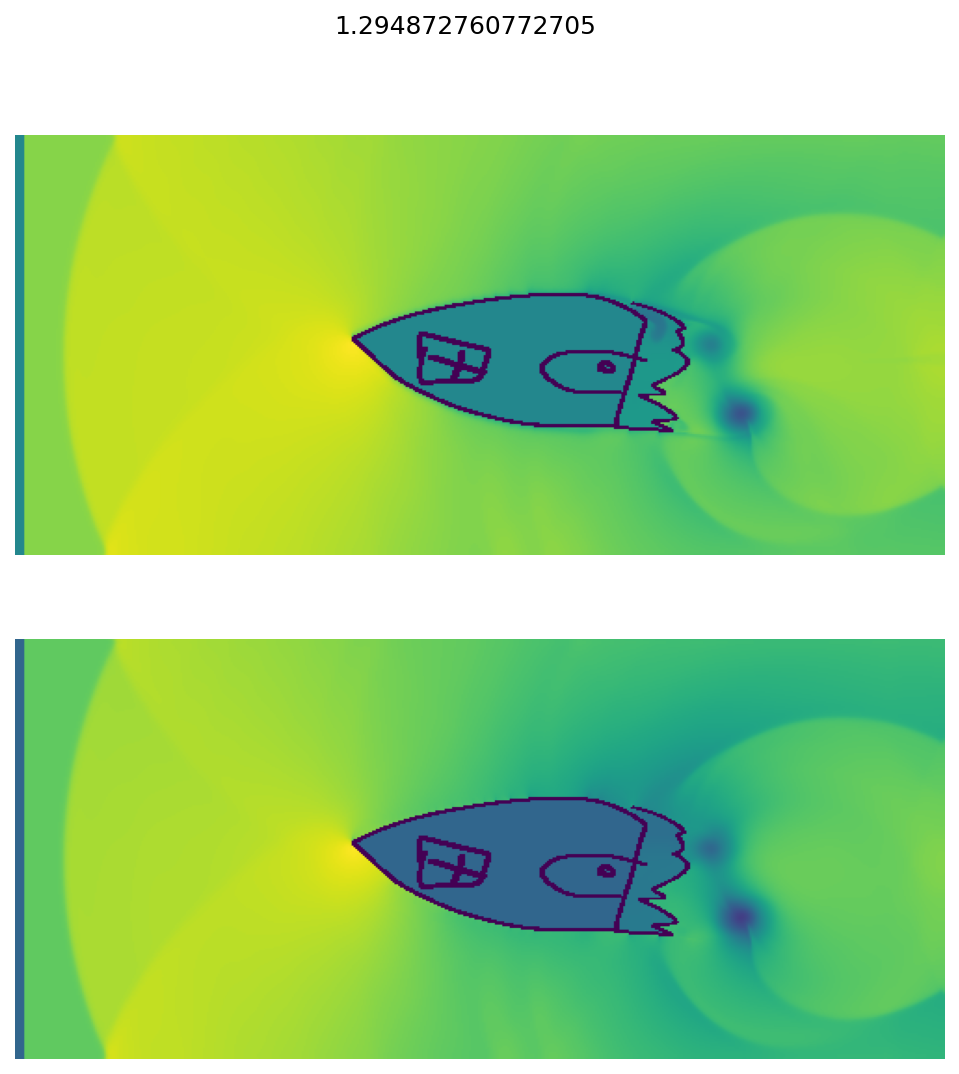

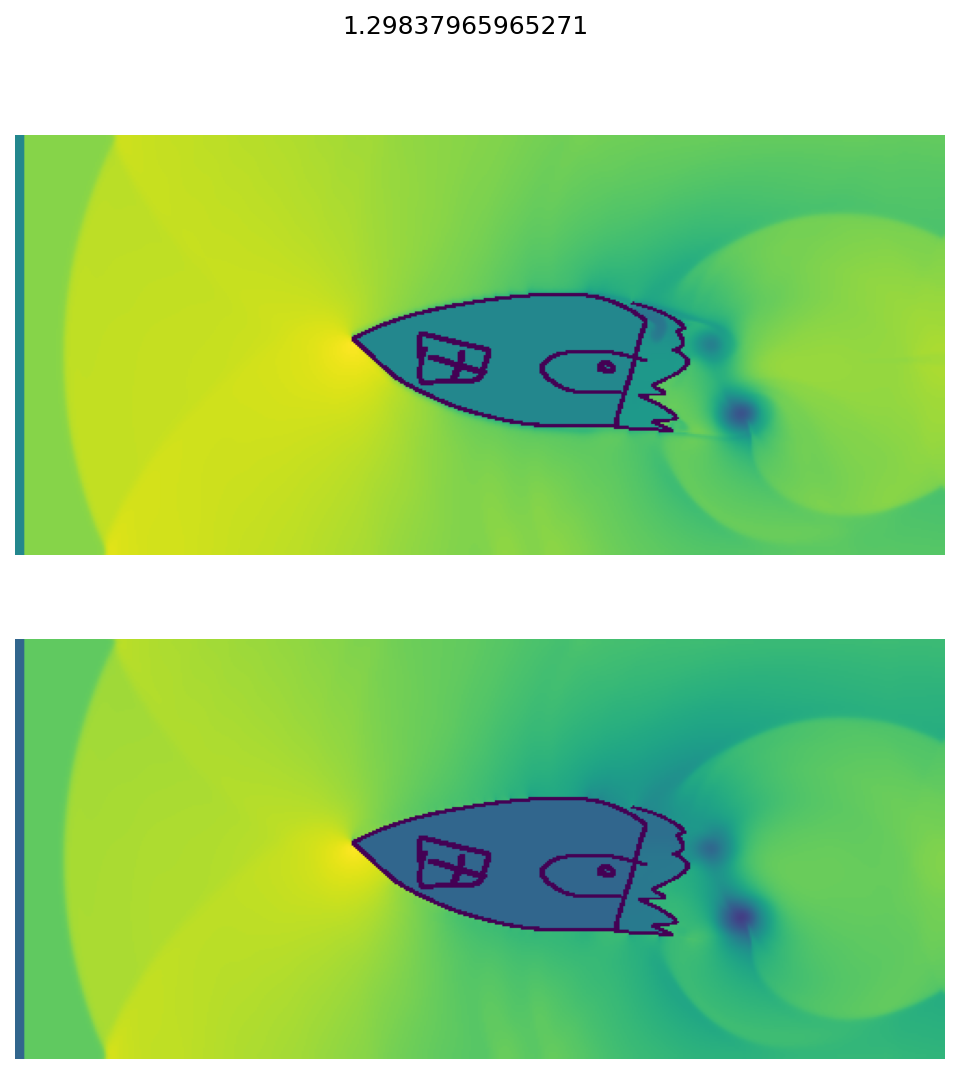

In [7]:
IV = ImageVisualizer((sim.get_images_num(), 1), record = True, save_path="./run", figsize=(8, 8))
IV.update(sim.get_images())


t = T_DOMAIN[0]
counter = 0
while t < T_DOMAIN[1]:
    counter += 1
    dt = sim.update()
    t += dt

    sim.cell[:, :, :5, 0] = rho_outer
    sim.cell[:, :, :5, 4] = p_outer
    sim.cell[:, :, :5, 1] = u_in

    if(counter % 3 == 0):
        torch.save(sim.cell.half(), f"{folder}/{t}.pt")
        IV.update(sim.get_images())
        IV.set_title(t.item())

    if(counter % 60 == 0):
        shutil.rmtree(folder_full, ignore_errors=True)
        os.makedirs(folder_full, exist_ok=True)
        torch.save(sim.cell, f"{folder_full}/{t}.pt")


In [8]:
IV.close()

All videos saved and closed.
